<a href="https://colab.research.google.com/github/JordanBaker78/Data201_JordanBaker/blob/main/Data201_Week5_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DATA 201 --- Week 5 Assignment

## Resampling Methods with the Iris Dataset

In this assignment, we will explore **bootstrap resampling, jackknife
resampling, and permutation tests** using the **Iris dataset**.

The Iris dataset contains measurements of iris flowers from three
species:

-   *Setosa*
-   *Versicolor*
-   *Virginica*

Each flower has four measurements:

-   sepal length
-   sepal width
-   petal length
-   petal width

------------------------------------------------------------------------

# Load the Dataset

Use the following code to load the dataset.

``` python
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

iris = sns.load_dataset("iris")
iris.head()
```


In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

iris = sns.load_dataset("iris")
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## Tasks

1.  Print the **number of observations** in the dataset.
2.  Print the **column names**.
3.  Count how many observations exist for each **species**.

------------------------------------------------------------------------

In [2]:
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [3]:
iris.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


# Part 1: Bootstrap Resampling

Estimate the **mean sepal length** using bootstrap resampling.

## Task 1 --- Basic Statistics

Compute the following statistics for **sepal length**:

-   mean
-   median
-   standard deviation

In [5]:
iris['sepal_length'].describe()

,sepal_length
count,150.000000
mean,5.843333
std,0.828066
min,4.300000
25%,5.100000
50%,5.800000
75%,6.400000
max,7.900000


In [6]:
iris['sepal_length'].median()

5.8

Senpal Length:

- Mean: 5.8433
- Median: 5.8
- Std: 0.828066

## Task 2 --- Bootstrap the Mean

Perform **5,000 bootstrap resamples**.

Procedure:

1.  Sample the dataset **with replacement**.
2.  Each sample must contain **150 observations**.
3.  Compute the **mean sepal length** for each resample.
4.  Store the results.

Plot the **distribution of bootstrap means**.

**Note on Efficiency**

While 5,000 iterations is manageable for 150 rows, consider the
computational cost if our dataset had **1 million rows**.
If your computer feels slow, try **1,000 iterations first**.

In [8]:
mean = 5.843333
median = 5.8
std = 0.828066

Population Mean: 5.84
Population Std: 0.825
Population Median: 5.8


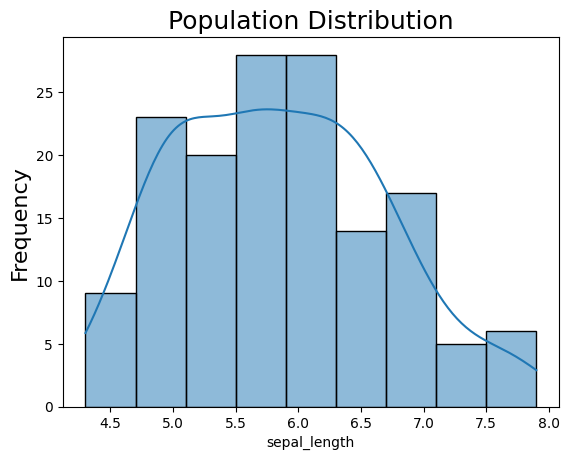

In [4]:
import numpy as np

population = iris['sepal_length'].dropna()
population_n = len(population)
mean = np.mean(population)
std = np.std(population)
median = np.median(population)

sns.histplot(population, kde=True, label='Population')
plt.title('Population Distribution', fontsize=18)
plt.ylabel('Frequency', fontsize=16)

print(f'Population Mean: {np.mean(population):.3}')
print(f'Population Std: {np.std(population):.3}')
print(f'Population Median: {np.median(population):.3}')

Sample Mean: 5.84
Sample Std: 0.825
Sample Median: 5.8


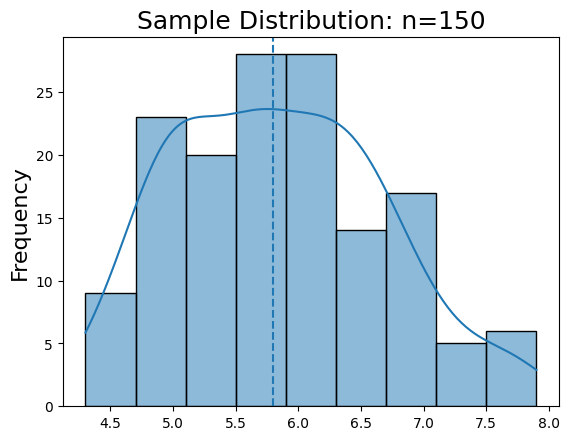

In [5]:
sample_n = 150
sample = np.random.choice(population, size=sample_n, replace=False)

sns.histplot(sample, kde=True, label='Single Sample')
plt.axvline(x=np.median(sample), ymin=0, ymax=1, linestyle='--')
plt.title(f'Sample Distribution: n={sample_n}', fontsize=18)
plt.ylabel('Frequency', fontsize=16)

print(f'Sample Mean: {np.mean(sample):.3}')
print(f'Sample Std: {np.std(sample):.3}')
print(f'Sample Median: {np.median(sample):.3}')

Bootstrapped Mean: 5.84
Bootstrapped Std: 0.0672


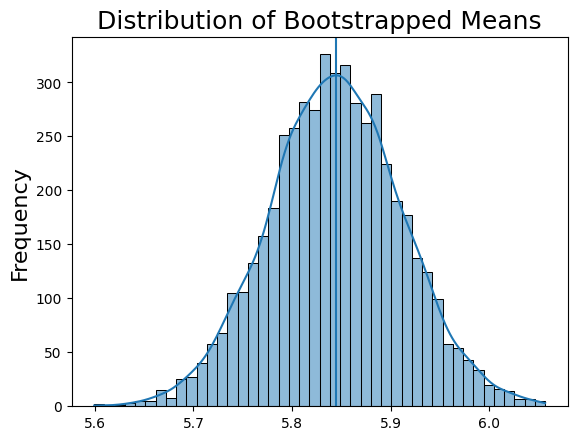

In [6]:
n_bootstrap = 5000

bootstrap_means = []
for b in range(n_bootstrap):
    bootstrap_means.append(np.mean(np.random.choice(sample, size=sample_n, replace=True)))
bootstrap_means = np.array(bootstrap_means)

sns.histplot(bootstrap_means, kde=True, label='Bootstrap')
plt.axvline(x=np.mean(bootstrap_means), ymin=0, ymax=1, linestyle='-')
plt.title('Distribution of Bootstrapped Means', fontsize=18)
plt.ylabel('Frequency', fontsize=16)

print(f'Bootstrapped Mean: {np.mean(bootstrap_means):.3}')
print(f'Bootstrapped Std: {np.std(bootstrap_means):.3}')

## Task 3 --- Confidence Interval

Using the bootstrap results, compute the **95% confidence interval**
using the percentile method:

CI = \[2.5%, 97.5%\]

Report:

-   Bootstrap mean
-   Lower bound
-   Upper bound


Bootstrapped Median: 5.84
95% Confidence Intervals: [5.71, 5.98]


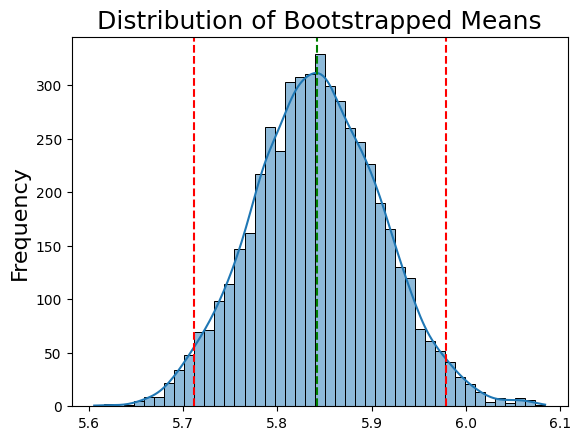

In [22]:
sns.histplot(bootstrap_means, kde=True, label='Bootstrap')
plt.axvline(x=np.median(bootstrap_means), ymin=0, ymax=1, color='green', linestyle='--')
plt.title('Distribution of Bootstrapped Means', fontsize=18)
plt.ylabel('Frequency', fontsize=16)

lower_bound = np.percentile(bootstrap_means, 2.5)
upper_bound = np.percentile(bootstrap_means, 97.5)

plt.axvline(x=lower_bound, ymin=0, ymax=1, color='red', linestyle='--')
plt.axvline(x=upper_bound, ymin=0, ymax=1, color='red', linestyle='--')

print(f'Bootstrapped Median: {np.mean(bootstrap_means):.3}')
print(f'95% Confidence Intervals: [{lower_bound:.3}, {upper_bound:.3}]')

### Question

Why is it mathematically necessary to sample **with replacement** in
bootstrap resampling?

------------------------------------------------------------------------

It is necessary because it allows a sample to simulate and act as mutliple samples within the population.

# Part 2 --- Jackknife Resampling

## Task 4 --- Jackknife the Mean

Create jackknife samples by removing **one observation at a time**.

Steps:

1.  For each observation i, remove it from the dataset.
2.  Compute the mean of the remaining observations.
3.  Store the result.

Plot the **distribution of jackknife means**.

**Visualization Tip**

Because you are removing only **one data point at a time**, the
resulting means will be extremely similar.
You may need to:

-   use a **large number of bins**, or
-   adjust `plt.xlim()`

to clearly see the variation.


In [7]:
def jackknife_resampling(sample):
    n = sample_n
    jackknife_means = np.zeros(n)
    for i in range(n):
        jackknife_sample = np.delete(sample, i)
        jackknife_means[i] = np.mean(jackknife_sample)

    jackknife_mean = np.mean(jackknife_means)

    original_mean = np.mean(sample)
    bias = (n - 1)*(original_mean - jackknife_mean)

    variance = (n - 1) * np.mean((jackknife_means - jackknife_mean) ** 2)

    return jackknife_mean, bias, variance, jackknife_means

mean, bias, variance, jackknife_means = jackknife_resampling(sample)
print(f"Jackknife Mean: {mean}")
print(f"Bias: {bias}")
print(f"Variance: {variance}")

Jackknife Mean: 5.843333333333334
Bias: 0.0
Variance: 0.0045712900820283784


Jackknife Mean: 5.84
Jackknife Std: 0.00554


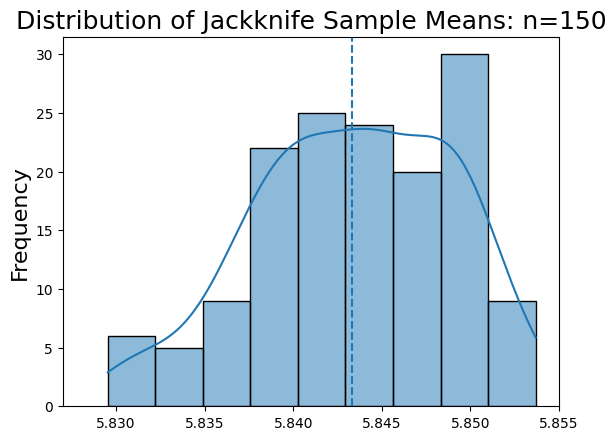

In [15]:
sns.histplot(jackknife_means, kde=True, label='Means of Jackknife Samples')
plt.axvline(x=np.mean(jackknife_means), ymin=0, ymax=1, linestyle='--')
plt.title(f'Distribution of Jackknife Sample Means: n={sample_n}', fontsize=18)
plt.ylabel('Frequency', fontsize=16)
plt.xlim(5.827, 5.855)

print(f'Jackknife Mean: {np.mean(jackknife_means):.3}')
print(f'Jackknife Std: {np.std(jackknife_means):.3}')

### Question

If the dataset contains n observations, **exactly how many jackknife
samples** are created?

------------------------------------------------------------------------
If a dataset has *n* observations, the number of Jackknife sampples will be = n, with the size of each sample being *n* - 1.


# Part 3 --- Permutation Test

We will test whether **sepal length differs significantly between two
species**.

For this task, use:

-   **Versicolor**
-   **Virginica**



## Task 5 --- Observed Statistic

Compute the observed difference in means:

difference = mean(Versicolor) − mean(Virginica)

------------------------------------------------------------------------

In [36]:
virginica = iris[iris['species'] == 'virginica']
veriscolor = iris[iris['species'] == 'versicolor']

virg_len = virginica['sepal_length']
veri_len = veriscolor['sepal_length']

In [50]:
print (virg_len)

100    6.3
101    5.8
102    7.1
103    6.3
104    6.5
105    7.6
106    4.9
107    7.3
108    6.7
109    7.2
110    6.5
111    6.4
112    6.8
113    5.7
114    5.8
115    6.4
116    6.5
117    7.7
118    7.7
119    6.0
120    6.9
121    5.6
122    7.7
123    6.3
124    6.7
125    7.2
126    6.2
127    6.1
128    6.4
129    7.2
130    7.4
131    7.9
132    6.4
133    6.3
134    6.1
135    7.7
136    6.3
137    6.4
138    6.0
139    6.9
140    6.7
141    6.9
142    5.8
143    6.8
144    6.7
145    6.7
146    6.3
147    6.5
148    6.2
149    5.9
Name: sepal_length, dtype: float64


In [39]:
mean_diff = np.mean(virg_len) - np.mean(veri_len)
print (mean_diff)

0.6519999999999984


## Task 6 --- Permutation Simulation

Run **1,000 permutations**.

Procedure:

1.  Combine the two species into one dataset.
2.  **Shuffle (permute) the labels**.
3.  Split the data back into two groups of the original sizes.
4.  Compute the difference in means.
5.  Store the result.

Plot the **permutation distribution**.

------------------------------------------------------------------------

In [59]:
all_lengths = pd.concat([virg_len, veri_len])
print (all_lengths)

100    6.3
101    5.8
102    7.1
103    6.3
104    6.5
      ... 
95     5.7
96     5.7
97     6.2
98     5.1
99     5.7
Name: sepal_length, Length: 100, dtype: float64


In [60]:
simu_diff = []
n_samples = 1000
n_virginica = len(virg_len)


In [61]:
for i in range(n_samples):
  perm_sample = np.random.permutation(all_lengths)
  perm_virginica = perm_sample[:n_virginica]
  perm_veriscolor = perm_sample[n_virginica:]
  perm_diff = np.mean(perm_virginica) - np.mean(perm_veriscolor)
  simu_diff.append(perm_diff)
  print (perm_diff)

0.3520000000000003
-0.17600000000000016
-0.004000000000002224
-0.13600000000000012
0.16799999999999926
0.043999999999999595
0.15200000000000102
0.18799999999999972
-0.32399999999999984
0.05200000000000049
0.22000000000000064
-0.06399999999999739
-0.02799999999999958
-0.08800000000000008
-0.2759999999999989
-0.120000000000001
0.16000000000000014
-0.04400000000000048
0.04800000000000004
0.09999999999999876
0.13199999999999967
0.1880000000000015
0.016000000000000014
-0.0039999999999995595
-0.14800000000000058
0.16399999999999793
0.05600000000000094
-0.01600000000000268
0.015999999999998238
-0.1880000000000006
-0.2760000000000016
0.128000000000001
-0.043999999999999595
0.28000000000000114
-0.06799999999999962
0.0600000000000005
0.023999999999999133
-0.128000000000001
-0.19199999999999928
0.07599999999999874
-0.02000000000000135
-0.008000000000000895
-0.019999999999999574
-0.09200000000000053
0.17600000000000016
-0.020000000000000462
-0.14000000000000146
0.10000000000000053
0.20399999999999

In [62]:
upper = np.quantile(simu_diff, 0.95)
lower = np.quantile(simu_diff, 0.05)
print(lower, upper)

-0.2202000000000005 0.21999999999999892


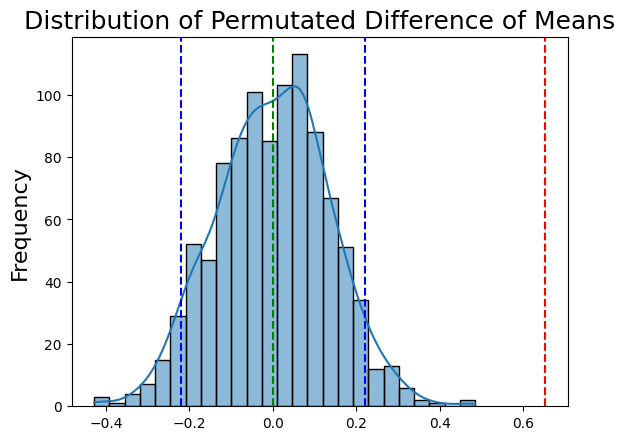

In [63]:
sns.histplot(simu_diff, kde=True, label='Permutation')
plt.axvline(x=np.mean(simu_diff), ymin=0, ymax=1, color='green', linestyle='--')
plt.axvline(x=mean_diff, ymin=0, ymax=1, color='red', linestyle='--')
plt.title('Distribution of Permutated Difference of Means', fontsize=18)
plt.ylabel('Frequency', fontsize=16)

plt.axvline(x=lower, ymin=0, ymax=1, color='blue', linestyle='--')
plt.axvline(x=upper, ymin=0, ymax=1, color='blue', linestyle='--')

## Task 7 --- p-value

Compute the p-value:

p = (number of simulated differences ≥ observed difference) / (total
simulations)

Interpret the result at α = 0.05.

------------------------------------------------------------------------

In [65]:
p_value = np.sum(np.abs(simu_diff) >= np.abs(mean_diff)) / 1000
print(f'p-value: {p_value}')

p-value: 0.0


In [66]:
print(f'Permutated Mean Difference: {np.mean(simu_diff):.3}')
print(f'95% Confidence Intervals: [{lower:.3}, {upper:.3}]')
print(f'Actual Difference of Means: {mean_diff:.3}')
print(f'p-value: {p_value:.3}')

Permutated Mean Difference: 0.000852
95% Confidence Intervals: [-0.22, 0.22]
Actual Difference of Means: 0.652
p-value: 0.0


A p-value of 0.0 suggests that it is nearly impossible to produce this data if the null hypothesis is true. The p-value is extremely strong evidence against the null hypothesis.

## Questions

1.  What is the **null hypothesis (H0)** in this specific test?
2.  What does the **permutation distribution** represent in terms of
    **random chance**?
3.  Based on your p-value, do you **reject** or **fail to reject** the
    null hypothesis?

------------------------------------------------------------------------

1. In this test, the null hypothesis would be that the Sepal Length of the Veriscolor and Virginia species does **not** differ significantly.
2. The premutation distribution represents the total number of possibilites assuming the null hypothesis is true.
3. Based on the p-value of 0.0, we can reject the null hypothesis and have strong evidence for the alternative.